# ThinkLab NLP Project

## Product Review Sentiment Classification

**Member:** Pawan  
**Machine Learning Model:** Naive Bayes  
**Deep Learning Model:** Convolutional Neural Network (CNN )

### Import Required Libraries

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
import joblib
import pickle
import shutil
import nltk
import tensorflow as tf

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
### Upload the Dataset

In [2]:
uploaded = files.upload()

Saving Womens Clothing E-Commerce Reviews.csv to Womens Clothing E-Commerce Reviews.csv


### Load and Preview the Dataset

In [3]:
filename = next(iter(uploaded))

# Load the dataset
dataset = pd.read_csv(filename)

print("Dataset loaded successfully.")
print("Dataset shape:", dataset.shape)

dataset.head()

Dataset loaded successfully.
Dataset shape: (23486, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


### Inspect Dataset Information

In [4]:
print("Dataset information:")
dataset.info()

print("\nMissing values:")
print(dataset.isnull().sum())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB

Missing values:
Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title             

### Select and Clean Required Columns

In [5]:
data = dataset[['Review Text', 'Rating']].copy()

print("Original records:", data.shape[0])

# Remove missing values
data = data.dropna(subset=['Review Text', 'Rating'])
print("After removing missing values:", data.shape[0])

# Remove duplicate records
data = data.drop_duplicates()
print("After removing duplicates:", data.shape[0])

# Reset index
data = data.reset_index(drop=True)

print("\nMissing values after cleaning:")
print(data.isnull().sum())

data.head()

Original records: 23486
After removing missing values: 22641
After removing duplicates: 22634

Missing values after cleaning:
Review Text    0
Rating         0
dtype: int64


,Review Text,Rating
0,Absolutely wonderful - silky and sexy and comf...,4
1,Love this dress! it's sooo pretty. i happene...,5
2,I had such high hopes for this dress and reall...,3
3,"I love, love, love this jumpsuit. it's fun, fl...",5
4,This shirt is very flattering to all due to th...,5


### Create Sentiment Labels

In [6]:
def create_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"


data['Sentiment'] = data['Rating'].apply(create_sentiment)

data[['Review Text', 'Rating', 'Sentiment']].head(10)

,Review Text,Rating,Sentiment
0,Absolutely wonderful - silky and sexy and comf...,4,Positive
1,Love this dress! it's sooo pretty. i happene...,5,Positive
2,I had such high hopes for this dress and reall...,3,Neutral
3,"I love, love, love this jumpsuit. it's fun, fl...",5,Positive
4,This shirt is very flattering to all due to th...,5,Positive
5,"I love tracy reese dresses, but this one is no...",2,Negative
6,I aded this in my basket at hte last mintue to...,5,Positive
7,"I ordered this in carbon for store pick up, an...",4,Positive
8,I love this dress. i usually get an xs but it ...,5,Positive
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",5,Positive


### Verify Rating and Sentiment Mapping

In [7]:
print(
    data[['Rating', 'Sentiment']]
    .drop_duplicates()
    .sort_values('Rating')
)

    Rating Sentiment
61       1  Negative
5        2  Negative
2        3   Neutral
0        4  Positive
1        5  Positive


### Count Sentiment Classes

In [8]:
sentiment_counts = data['Sentiment'].value_counts()

print("Sentiment class counts:")
print(sentiment_counts)

Sentiment class counts:
Sentiment
Positive    17442
Neutral      2823
Negative     2369
Name: count, dtype: int64


### Visualize Sentiment Distribution

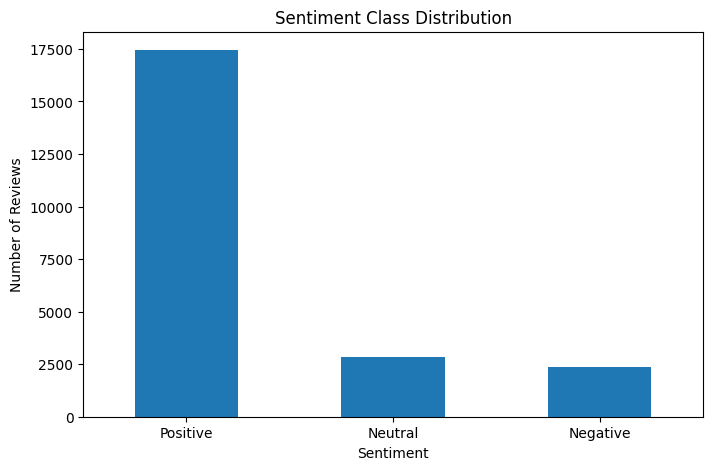

In [9]:
sentiment_counts.plot(kind='bar', figsize=(8, 5))

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

### Download NLTK Resources

In [10]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("NLTK resources downloaded successfully.")

NLTK resources downloaded successfully.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


### Perform Basic Text Cleaning

In [11]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


data['Cleaned Review'] = data['Review Text'].apply(clean_text)

data[['Review Text', 'Cleaned Review']].head(10)

,Review Text,Cleaned Review
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky and sexy and comfor...
1,Love this dress! it's sooo pretty. i happene...,love this dress it s sooo pretty i happened to...
2,I had such high hopes for this dress and reall...,i had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl...",i love love love this jumpsuit it s fun flirty...
4,This shirt is very flattering to all due to th...,this shirt is very flattering to all due to th...
5,"I love tracy reese dresses, but this one is no...",i love tracy reese dresses but this one is not...
6,I aded this in my basket at hte last mintue to...,i aded this in my basket at hte last mintue to...
7,"I ordered this in carbon for store pick up, an...",i ordered this in carbon for store pick up and...
8,I love this dress. i usually get an xs but it ...,i love this dress i usually get an xs but it r...
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",i m and lbs i ordered the s petite to make sur...


### Apply Advanced Text Preprocessing

In [12]:
# Prepare stop words
stop_words = set(stopwords.words('english'))

# Preserve important negative words
stop_words.discard('not')
stop_words.discard('no')
stop_words.discard('nor')

# Create lemmatizer
lemmatizer = WordNetLemmatizer()


def process_text(text):
    # Tokenize the text
    words = text.split()

    # Remove stop words and apply lemmatization
    processed_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(processed_words)


data['Processed Review'] = data['Cleaned Review'].apply(process_text)

data[
    ['Review Text', 'Cleaned Review', 'Processed Review']
].head(10)

,Review Text,Cleaned Review,Processed Review
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky and sexy and comfor...,absolutely wonderful silky sexy comfortable
1,Love this dress! it's sooo pretty. i happene...,love this dress it s sooo pretty i happened to...,love dress sooo pretty happened find store gla...
2,I had such high hopes for this dress and reall...,i had such high hopes for this dress and reall...,high hope dress really wanted work initially o...
3,"I love, love, love this jumpsuit. it's fun, fl...",i love love love this jumpsuit it s fun flirty...,love love love jumpsuit fun flirty fabulous ev...
4,This shirt is very flattering to all due to th...,this shirt is very flattering to all due to th...,shirt flattering due adjustable front tie perf...
5,"I love tracy reese dresses, but this one is no...",i love tracy reese dresses but this one is not...,love tracy reese dress one not petite foot tal...
6,I aded this in my basket at hte last mintue to...,i aded this in my basket at hte last mintue to...,aded basket hte last mintue see would look lik...
7,"I ordered this in carbon for store pick up, an...",i ordered this in carbon for store pick up and...,ordered carbon store pick ton stuff always try...
8,I love this dress. i usually get an xs but it ...,i love this dress i usually get an xs but it r...,love dress usually get x run little snug bust ...
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",i m and lbs i ordered the s petite to make sur...,lb ordered petite make sure length long typica...


### Check Empty Processed Reviews

In [13]:
empty_cleaned = (data['Cleaned Review'].str.len() == 0).sum()
empty_processed = (data['Processed Review'].str.len() == 0).sum()

print("Empty cleaned reviews:", empty_cleaned)
print("Empty processed reviews:", empty_processed)

Empty cleaned reviews: 0
Empty processed reviews: 0


### Split the Dataset

In [14]:
train_data, test_data = train_test_split(
    data,
    test_size=0.20,
    random_state=42,
    stratify=data['Sentiment']
)

print("Training records:", train_data.shape[0])
print("Testing records:", test_data.shape[0])

print("\nTraining sentiment distribution:")
print(train_data['Sentiment'].value_counts())

print("\nTesting sentiment distribution:")
print(test_data['Sentiment'].value_counts())

Training records: 18107
Testing records: 4527

Training sentiment distribution:
Sentiment
Positive    13954
Neutral      2258
Negative     1895
Name: count, dtype: int64

Testing sentiment distribution:
Sentiment
Positive    3488
Neutral      565
Negative     474
Name: count, dtype: int64


## Naive Bayes Model

### Create TF-IDF Features

In [15]:
nb_tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

# Fit only on training data
X_train_tfidf = nb_tfidf.fit_transform(
    train_data['Processed Review']
)

# Transform testing data
X_test_tfidf = nb_tfidf.transform(
    test_data['Processed Review']
)

y_train_nb = train_data['Sentiment']
y_test_nb = test_data['Sentiment']

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (18107, 10000)
Testing TF-IDF shape: (4527, 10000)


### Train the Naive Bayes Model

In [16]:
naive_bayes_model = ComplementNB(alpha=0.5)

# Train the model
naive_bayes_model.fit(
    X_train_tfidf,
    y_train_nb
)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


### Generate Naive Bayes Predictions

In [17]:
nb_predictions = naive_bayes_model.predict(
    X_test_tfidf
)

print("Naive Bayes predictions generated successfully.")

Naive Bayes predictions generated successfully.


### Evaluate the Naive Bayes Model

In [18]:
# Calculate evaluation metrics
nb_accuracy = accuracy_score(
    y_test_nb,
    nb_predictions
)

nb_macro_precision = precision_score(
    y_test_nb,
    nb_predictions,
    average='macro',
    zero_division=0
)

nb_macro_recall = recall_score(
    y_test_nb,
    nb_predictions,
    average='macro',
    zero_division=0
)

nb_macro_f1 = f1_score(
    y_test_nb,
    nb_predictions,
    average='macro',
    zero_division=0
)

print("Naive Bayes Accuracy:", round(nb_accuracy, 4))
print(
    "Naive Bayes Macro Precision:",
    round(nb_macro_precision, 4)
)
print(
    "Naive Bayes Macro Recall:",
    round(nb_macro_recall, 4)
)
print(
    "Naive Bayes Macro F1-Score:",
    round(nb_macro_f1, 4)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_nb,
        nb_predictions,
        digits=4,
        zero_division=0
    )
)

Naive Bayes Accuracy: 0.7813
Naive Bayes Macro Precision: 0.5732
Naive Bayes Macro Recall: 0.6328
Naive Bayes Macro F1-Score: 0.5943

Classification Report:
              precision    recall  f1-score   support

    Negative     0.4331    0.6561    0.5218       474
     Neutral     0.3381    0.3788    0.3573       565
    Positive     0.9484    0.8635    0.9040      3488

    accuracy                         0.7813      4527
   macro avg     0.5732    0.6328    0.5943      4527
weighted avg     0.8182    0.7813    0.7957      4527



### Naive Bayes Confusion Matrix

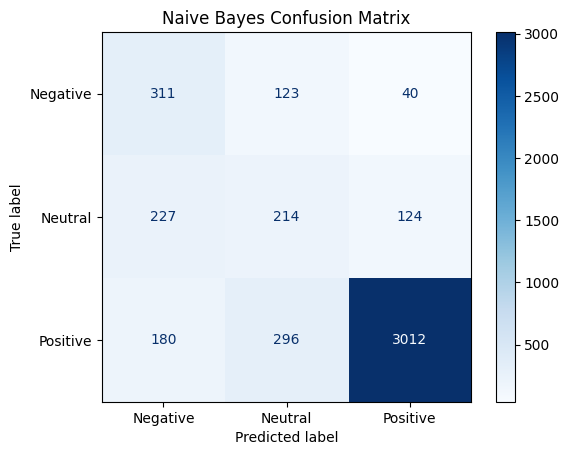

In [19]:
ConfusionMatrixDisplay.from_predictions(
    y_test_nb,
    nb_predictions,
    labels=['Negative', 'Neutral', 'Positive'],
    cmap='Blues'
)

plt.title("Naive Bayes Confusion Matrix")
plt.show()

### Save the Naive Bayes Model

In [20]:
os.makedirs("models", exist_ok=True)

# Save Naive Bayes model
joblib.dump(
    naive_bayes_model,
    "models/pawan_naive_bayes_model.pkl"
)

# Save TF-IDF vectorizer
joblib.dump(
    nb_tfidf,
    "models/pawan_tfidf_vectorizer.pkl"
)

print("Naive Bayes model and vectorizer saved successfully.")

Naive Bayes model and vectorizer saved successfully.


## Convolutional Neural Network Model

### Encode Sentiment Labels

In [21]:
# Create label encoder
label_encoder = LabelEncoder()

# Fit encoder using training labels
y_train_cnn = label_encoder.fit_transform(
    train_data['Sentiment']
)

# Transform testing labels
y_test_cnn = label_encoder.transform(
    test_data['Sentiment']
)

print("Label mapping:")

for index, label in enumerate(label_encoder.classes_):
    print(index, "=", label)

Label mapping:
0 = Negative
1 = Neutral
2 = Positive


### Tokenize and Pad the Reviews

In [22]:
# CNN parameters
vocab_size = 10000
max_length = 100

# Create tokenizer
cnn_tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

# Fit tokenizer only on training reviews
cnn_tokenizer.fit_on_texts(
    train_data['Cleaned Review']
)

# Convert text into sequences
X_train_sequences = cnn_tokenizer.texts_to_sequences(
    train_data['Cleaned Review']
)

X_test_sequences = cnn_tokenizer.texts_to_sequences(
    test_data['Cleaned Review']
)

# Pad sequences
X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("CNN training shape:", X_train_padded.shape)
print("CNN testing shape:", X_test_padded.shape)

CNN training shape: (18107, 100)
CNN testing shape: (4527, 100)


### Calculate CNN Class Weights

In [23]:
# Get unique classes
cnn_classes = np.unique(y_train_cnn)

# Calculate balanced class weights
cnn_weights = compute_class_weight(
    class_weight='balanced',
    classes=cnn_classes,
    y=y_train_cnn
)

cnn_class_weights = dict(
    zip(cnn_classes, cnn_weights)
)

print("CNN class weights:")
print(cnn_class_weights)

CNN class weights:
{np.int64(0): np.float64(3.1850483729111696), np.int64(1): np.float64(2.673014467080012), np.int64(2): np.float64(0.4325402513018967)}


### Build the CNN Model

In [24]:
# Build the CNN model
cnn_model = Sequential([
    Input(shape=(max_length,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),

    Conv1D(
        filters=64,
        kernel_size=5,
        activation='relu'
    ),

    GlobalMaxPooling1D(),

    Dropout(0.5),

    Dense(
        32,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        3,
        activation='softmax'
    )
])

# Compile the model
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 96, 64)         │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 662,723 (2.53 MB)

 Trainable params: 662,723 (2.53 MB)

 Non-trainable params: 0 (0.00 B)

### Train the CNN Model

In [25]:
# Stop training when validation loss does not improve
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Train the CNN model
cnn_history = cnn_model.fit(
    X_train_padded,
    y_train_cnn,
    validation_split=0.20,
    epochs=6,
    batch_size=64,
    class_weight=cnn_class_weights,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/6
227/227 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.4701 - loss: 1.0650 - val_accuracy: 0.7159 - val_loss: 0.7860
Epoch 2/6
227/227 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.7011 - loss: 0.8689 - val_accuracy: 0.7601 - val_loss: 0.6056
Epoch 3/6
227/227 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.7696 - loss: 0.7456 - val_accuracy: 0.7772 - val_loss: 0.5636
Epoch 4/6
227/227 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.8068 - loss: 0.6557 - val_accuracy: 0.7786 - val_loss: 0.5453
Epoch 5/6
227/227 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.8349 - loss: 0.5783 - val_accuracy: 0.7860 - val_loss: 0.5430
Epoch 6/6
227/227 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.8545 - loss: 0.5001 - val_accuracy: 0.7866 - val_loss: 0.5848


### Visualize CNN Training Performance

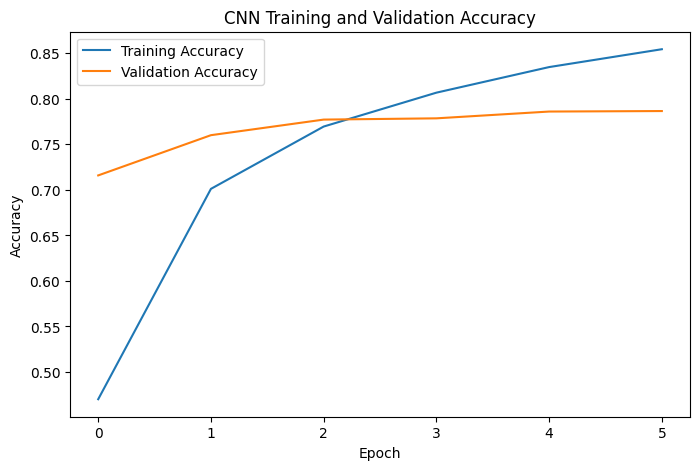

In [26]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Visualize CNN Training Loss


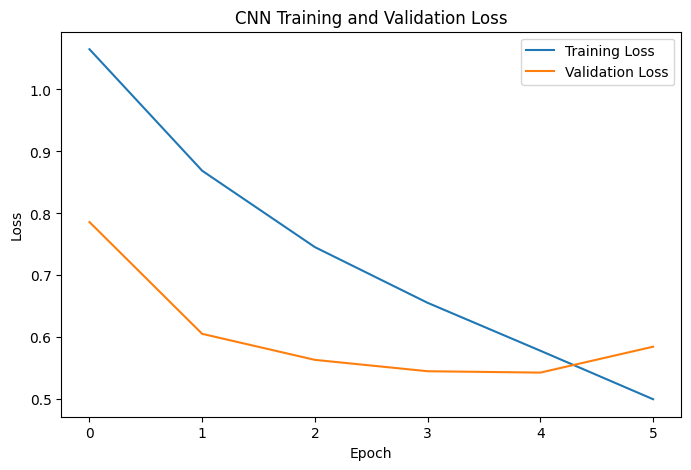

In [27]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    cnn_history.history['val_loss'],
    label='Validation Loss'
)

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Generate CNN Predictions

In [28]:
# Generate prediction probabilities
cnn_probabilities = cnn_model.predict(
    X_test_padded
)

# Select the class with highest probability
cnn_prediction_numbers = np.argmax(
    cnn_probabilities,
    axis=1
)

# Convert numbers back into sentiment labels
cnn_predictions = label_encoder.inverse_transform(
    cnn_prediction_numbers
)

y_test_cnn_labels = label_encoder.inverse_transform(
    y_test_cnn
)

print("CNN predictions generated successfully.")

142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
CNN predictions generated successfully.


### Evaluate the CNN Model

In [29]:
# Calculate CNN evaluation metrics
cnn_accuracy = accuracy_score(
    y_test_cnn_labels,
    cnn_predictions
)

cnn_macro_precision = precision_score(
    y_test_cnn_labels,
    cnn_predictions,
    average='macro',
    zero_division=0
)

cnn_macro_recall = recall_score(
    y_test_cnn_labels,
    cnn_predictions,
    average='macro',
    zero_division=0
)

cnn_macro_f1 = f1_score(
    y_test_cnn_labels,
    cnn_predictions,
    average='macro',
    zero_division=0
)

print("CNN Accuracy:", round(cnn_accuracy, 4))
print(
    "CNN Macro Precision:",
    round(cnn_macro_precision, 4)
)
print(
    "CNN Macro Recall:",
    round(cnn_macro_recall, 4)
)
print(
    "CNN Macro F1-Score:",
    round(cnn_macro_f1, 4)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_cnn_labels,
        cnn_predictions,
        digits=4,
        zero_division=0
    )
)

CNN Accuracy: 0.7941
CNN Macro Precision: 0.6395
CNN Macro Recall: 0.6333
CNN Macro F1-Score: 0.6227

Classification Report:
              precision    recall  f1-score   support

    Negative     0.6356    0.4599    0.5337       474
     Neutral     0.3457    0.5628    0.4283       565
    Positive     0.9372    0.8770    0.9061      3488

    accuracy                         0.7941      4527
   macro avg     0.6395    0.6333    0.6227      4527
weighted avg     0.8318    0.7941    0.8075      4527



### CNN Confusion Matrix

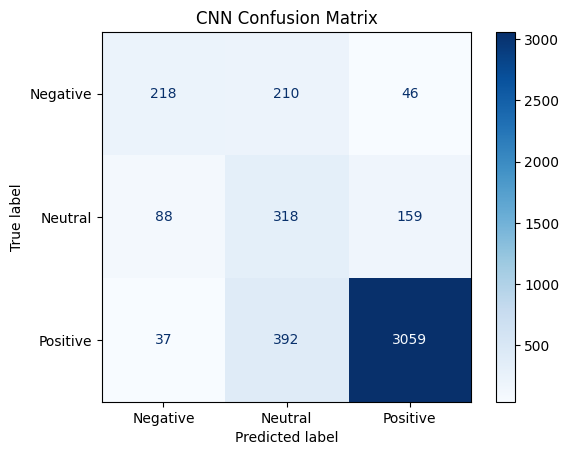

In [30]:
# Display CNN confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_cnn_labels,
    cnn_predictions,
    labels=['Negative', 'Neutral', 'Positive'],
    cmap='Blues'
)

plt.title("CNN Confusion Matrix")
plt.show()

### Save the CNN Model

In [31]:
# Save CNN model
cnn_model.save(
    "models/pawan_cnn_model.keras"
)

# Save CNN tokenizer
with open(
    "models/pawan_cnn_tokenizer.pkl",
    "wb"
) as file:
    pickle.dump(cnn_tokenizer, file)

# Save label encoder
with open(
    "models/pawan_label_encoder.pkl",
    "wb"
) as file:
    pickle.dump(label_encoder, file)

print("CNN model, tokenizer, and label encoder saved successfully.")

CNN model, tokenizer, and label encoder saved successfully.


## Model Performance Comparison

In [32]:
# Create model comparison table
comparison_data = {
    "Model": [
        "Naive Bayes",
        "CNN"
    ],

    "Accuracy": [
        nb_accuracy,
        cnn_accuracy
    ],

    "Macro Precision": [
        nb_macro_precision,
        cnn_macro_precision
    ],

    "Macro Recall": [
        nb_macro_recall,
        cnn_macro_recall
    ],

    "Macro F1-Score": [
        nb_macro_f1,
        cnn_macro_f1
    ]
}

comparison_df = pd.DataFrame(
    comparison_data
)

comparison_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
0,Naive Bayes,0.781312,0.573194,0.632804,0.594345
1,CNN,0.794124,0.639471,0.633251,0.622681


### Model Performance Comparison Chart

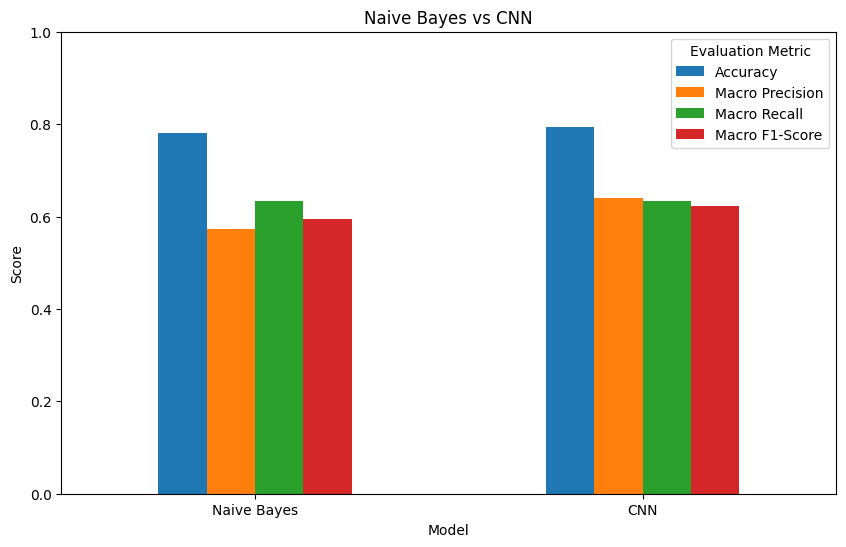

In [33]:
# Plot model comparison
comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Naive Bayes vs CNN")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Evaluation Metric")
plt.show()

### Best Performing Model

In [34]:
# Select the model with the highest macro F1-score
best_model_name = comparison_df.loc[
    comparison_df['Macro F1-Score'].idxmax(),
    'Model'
]

best_macro_f1 = comparison_df[
    'Macro F1-Score'
].max()

print("Best model:", best_model_name)
print(
    "Best Macro F1-Score:",
    round(best_macro_f1, 4)
)

Best model: CNN
Best Macro F1-Score: 0.6227


## Custom Review Sentiment Prediction

In [35]:
# Enter a custom review
custom_review = (
    "The dress is beautiful, comfortable, "
    "and fits perfectly."
)

# Preprocess for Naive Bayes
custom_cleaned = clean_text(custom_review)
custom_processed = process_text(custom_cleaned)

custom_tfidf = nb_tfidf.transform(
    [custom_processed]
)

nb_custom_prediction = naive_bayes_model.predict(
    custom_tfidf
)[0]

# Preprocess for CNN
custom_sequence = cnn_tokenizer.texts_to_sequences(
    [custom_cleaned]
)

custom_padded = pad_sequences(
    custom_sequence,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

cnn_custom_probability = cnn_model.predict(
    custom_padded
)

cnn_custom_number = np.argmax(
    cnn_custom_probability,
    axis=1
)

cnn_custom_prediction = label_encoder.inverse_transform(
    cnn_custom_number
)[0]

print("Review:", custom_review)
print(
    "Naive Bayes Prediction:",
    nb_custom_prediction
)
print(
    "CNN Prediction:",
    cnn_custom_prediction
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Review: The dress is beautiful, comfortable, and fits perfectly.
Naive Bayes Prediction: Positive
CNN Prediction: Positive


In [ ]:
### Create a ZIP File of Saved Models

In [36]:
# Create ZIP file
shutil.make_archive(
    "pawan_models",
    "zip",
    "models"
)

print("Pawan model ZIP file created successfully.")

Pawan model ZIP file created successfully.
